## Seminar and homework (10 points total)

Today we shall compose encoder-decoder neural networks and apply them to the task of machine translation.

![img](https://esciencegroup.files.wordpress.com/2016/03/seq2seq.jpg)
_(img: esciencegroup.files.wordpress.com)_


Encoder-decoder architectures are about converting anything to anything, including
 * Machine translation and spoken dialogue systems
 * [Image captioning](http://mscoco.org/dataset/#captions-challenge2015) and [image2latex](https://openai.com/requests-for-research/#im2latex) (convolutional encoder, recurrent decoder)
 * Generating [images by captions](https://arxiv.org/abs/1511.02793) (recurrent encoder, convolutional decoder)
 * Grapheme2phoneme - convert words to transcripts

## Our task: machine translation

We gonna try our encoder-decoder models on russian to english machine translation problem. More specifically, we'll translate hotel and hostel descriptions. This task shows the scale of machine translation while not requiring you to train your model for weeks if you don't use GPU.

Before we get to the architecture, there's some preprocessing to be done. ~~Go tokenize~~ Alright, this time we've done preprocessing for you. As usual, the data will be tokenized with WordPunctTokenizer.

However, there's one more thing to do. Our data lines contain unique rare words. If we operate on a word level, we will have to deal with large vocabulary size. If instead we use character-level models, it would take lots of iterations to process a sequence. This time we're gonna pick something inbetween.

One popular approach is called [Byte Pair Encoding](https://github.com/rsennrich/subword-nmt) aka __BPE__. The algorithm starts with a character-level tokenization and then iteratively merges most frequent pairs for N iterations. This results in frequent words being merged into a single token and rare words split into syllables or even characters.



In [ ]:
# !pip3 install torch>=1.3.0
# !pip3 install subword-nmt &> log
# !wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt
# !wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/week04_seq2seq/vocab.py -O vocab.py
# # thanks to tilda and deephack teams for the data, Dmitry Emelyanenko for the code :)

In [1]:
!pip install subword-nmt
import urllib.request

urllib.request.urlretrieve(
    "https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1",
    "data.txt"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/week04_seq2seq/vocab.py",
    "vocab.py"
)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


('vocab.py', <http.client.HTTPMessage at 0x211036ffa10>)

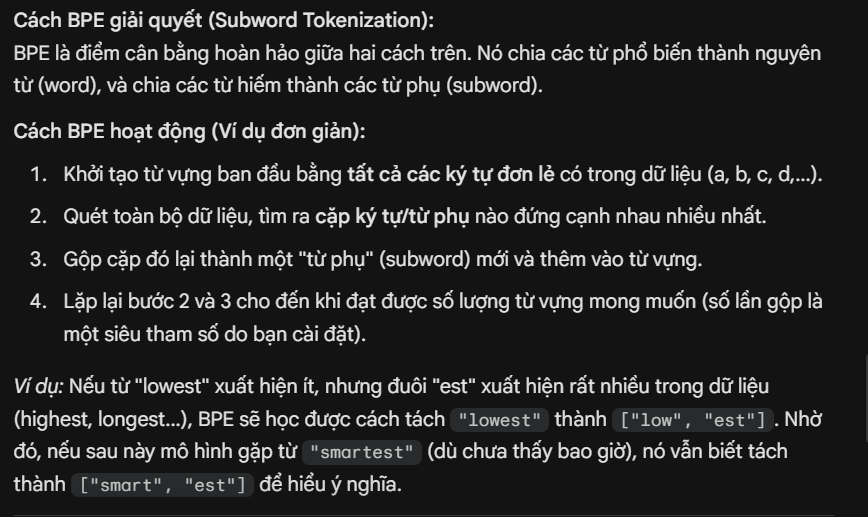

In [2]:
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

tokenizer = WordPunctTokenizer()

def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

# 1. Split and tokenize the data
# Thêm encoding='utf-8' cho cả file đọc và file ghi
with open('train.en', 'w', encoding='utf-8') as f_src, open('train.ru', 'w', encoding='utf-8') as f_dst:
    for line in open('data.txt', encoding='utf-8'):
        src_line, dst_line = line.strip().split('\t')
        f_src.write(tokenize(src_line) + '\n')
        f_dst.write(tokenize(dst_line) + '\n')

# 2. Build and apply BPE vocs
bpe = {}
for lang in ['en', 'ru']:
    # Thêm encoding='utf-8' vào tất cả các hàm open() ở bước huấn luyện BPE
    with open('./train.' + lang, encoding='utf-8') as f_in, open('bpe_rules.' + lang, 'w', encoding='utf-8') as f_out:
        learn_bpe(f_in, f_out, num_symbols=8000) # học từ f_in  thực hiện gộp các cặp bổ biến đúng 8000 lần -> bộ từ vựng cuỗi cỡ 8000 subwords
    
    with open('bpe_rules.' + lang, encoding='utf-8') as f_rules: # chỉ đọc file lên RAM
        bpe[lang] = BPE(f_rules) # bỏ quy tắc tương ứng lang vào dictionary

    # Thêm encoding='utf-8' khi áp dụng BPE vào tập train
    with open('train.bpe.' + lang, 'w', encoding='utf-8') as f_out: # đây là file train sau khi đã thực hiện cắt subword 
        for line in open('train.' + lang, encoding='utf-8'):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|██████████| 8000/8000 [00:05<00:00, 1432.53it/s]


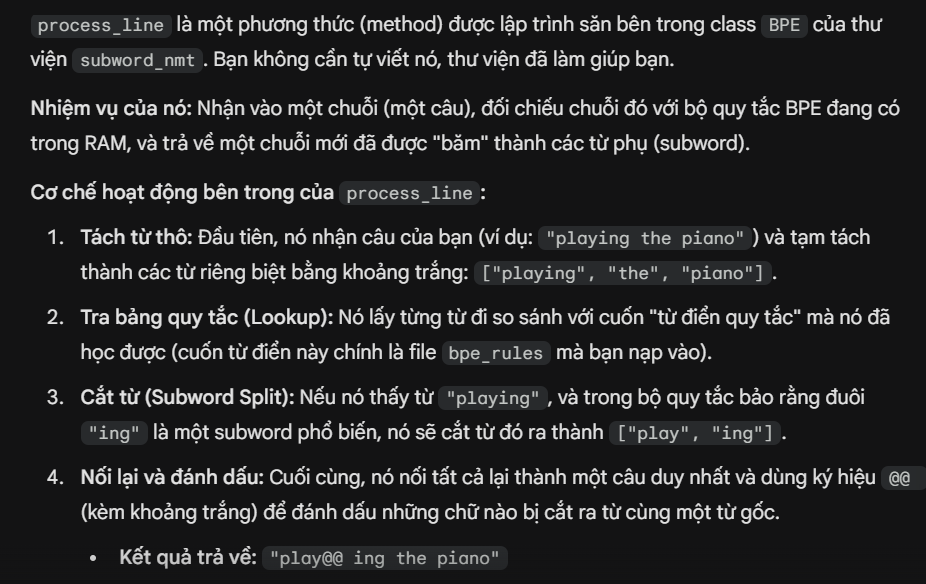

### Building vocabularies

We now need to build vocabularies that map strings to token ids and vice versa. We're gonna need these fellas when we feed training data into model or convert output matrices into words.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# Thêm encoding='utf-8' vào cả 2 hàm open()
data_inp = np.array(open('./train.bpe.ru', encoding='utf-8').read().split('\n'))
data_out = np.array(open('./train.bpe.en', encoding='utf-8').read().split('\n'))

train_inp, dev_inp, train_out, dev_out = train_test_split(
    data_inp, 
    data_out, 
    test_size=3000,
    random_state=42
)

for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [ ]:
from vocab import Vocab # tạo từ điển cho vào và ra từ corpus tương ứng nhau
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [6]:
# Here's how you cast lines into ids and backwards.
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('гостевой дом r .'), np.str_('до афин — 20 км .'), np.str_('работает боулинг .'), np.str_('оборудован балкон .'), np.str_('подключен wi - fi .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1108,   29,    1,    1,    1],
        [   0, 2922, 1834, 8035,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1]])

back to words
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']


Draw source and translation length distributions to estimate the scope of the task.

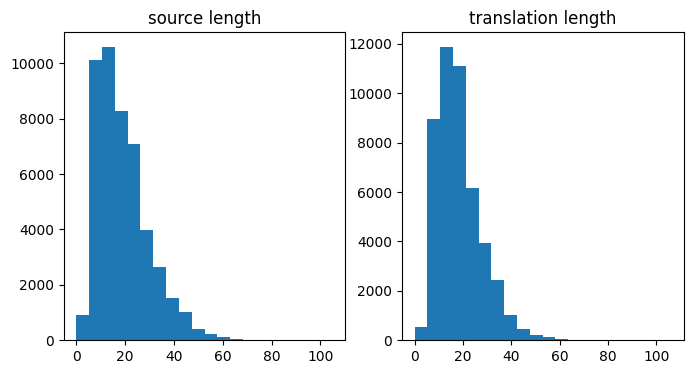

In [12]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

### Encoder-decoder model

The code below contains a template for a simple encoder-decoder model: single GRU encoder/decoder, no attention or anything. This model is implemented for you as a reference and a baseline for your homework assignment.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__() # initialize base class to track sub-layers, parameters, etc. / khởi tạo lớp cha để theo dõi các lớp con, tham số, v.v.

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp) # chuyển mảng subword thành embeđing cho máy hiểu 
        batch_size = inp.shape[0]

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]
        # enc_seq: chuỗi đầu ra mã hóa, last_state: trạng thái ẩn

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        # lưu ý: last_state không thực sự là cuối cùng do có padding (kí tự đệm), hãy tìm last_state thực sự
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1) # clamp_max đảm bảo không truy cập ngoài mảng 
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]
        # ^-- kích thước: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]

        # 1. Look up embeddings for previous tokens
        # 1. Lấy vector nhúng cho các token của bước trước đó
        prev_emb = self.emb_out(prev_tokens)
        
        # 2. Update GRU state
        # 2. Cập nhật trạng thái GRU (truyền vector nhúng và trạng thái cũ vào GRUCell)
        new_gru0_state = self.dec0(prev_emb, prev_gru0_state)
        
        # 3. Compute output logits
        # 3. Tính toán logits (điểm số phân phối xác suất cho từ vựng tiếp theo)
        output_logits = self.logits(new_gru0_state)
        
        # 4. Pack the new state into a list to match the format of prev_state
        # 4. Đóng gói trạng thái mới vào list để đồng nhất định dạng với prev_state
        new_dec_state = [new_gru0_state]

        return new_dec_state, output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        # logits ban đầu: luôn luôn dự đoán thẻ BOS (Begin Of Sentence - Bắt đầu câu)
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

In [10]:
# debugging area
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [11]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)

print("\nTranslations without training:")
print('\n'.join([line for line in dummy_translations]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
banquet clus@@ schö@@ ota cebu il phil@@ zhi@@ zhi@@ órdoba órdoba airs amid teresa aut@@ casale dre@@ cang@@ dallas arca@@ aren@@ sons ell and san
they decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated decorated
may malls gel fair@@ kan@@ pietro both jur@@ isaac groves ecuti@@ gu@@ nie marqu@@ dae 10@@ little kil@@ at atlanta coloured coloured rides pietro ô


### Training loss (2 points)

Our training objective is almost the same as it was for neural language models:
$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

where $|D|$ is the __total length of all sequences__, including BOS and first EOS, but excluding PAD.

In [12]:
import torch
import torch.nn.functional as F

def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    Tính độ lỗi (vô hướng float32) theo công thức
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]
    
    In order to pass the tests, your function should
    Để vượt qua các bài kiểm tra, hàm của bạn cần phải
    * include loss at first EOS but not the subsequent ones
    * bao gồm loss tại thẻ EOS (kết thúc câu) đầu tiên nhưng bỏ qua các thẻ EOS sau đó
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    * chia tổng loss cho tổng độ dài đầu vào (sử dụng voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    # Tạo mặt nạ (mask) để đánh dấu các token hợp lệ (không phải padding)

    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)
    # Chuyển nhãn (mục tiêu) sang dạng ma trận one-hot
    
    # outputs of the model, [batch_size, out_len, num_tokens]
    # đầu ra của mô hình (logits chưa qua hàm softmax)
    logits_seq = model(inp, out, **flags)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    # tính logarit xác suất của tất cả các token ở mọi bước thời gian
    logprobs_seq = F.log_softmax(logits_seq, dim=-1)
    
    # log-probabilities of correct outputs, [batch_size, out_len]
    # logarit xác suất của các từ vựng đúng với mục tiêu
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # ^-- phép toán này sẽ trích xuất ra xác suất của từ vựng thực tế tiếp theo.
    # Note: you can compute loss more efficiently using F.cross_entropy
    # Lưu ý: bạn có thể tính loss hiệu quả hơn bằng cách dùng thẳng F.cross_entropy

    # average cross-entropy over tokens where mask == True
    # tính trung bình cross-entropy trên các token hợp lệ (nơi mask == True)
    # Loss = -log(p). Chúng ta nhân với mask để triệt tiêu các từ đệm, sau đó tính tổng và chia cho tổng số từ hợp lệ.
    return -(logp_out * mask).sum() / mask.sum() # average loss, scalar

In [13]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.5520, device='cuda:0', grad_fn=<DivBackward0>)


### Evaluation: BLEU

Machine translation is commonly evaluated with [BLEU](https://en.wikipedia.org/wiki/BLEU) score. This metric simply computes which fraction of predicted n-grams is actually present in the reference translation. It does so for n=1,2,3 and 4 and computes the geometric average with penalty if translation is shorter than reference.

While BLEU [has many drawbacks](http://www.cs.jhu.edu/~ccb/publications/re-evaluating-the-role-of-bleu-in-mt-research.pdf), it still remains the most commonly used metric and one of the simplest to compute.

In [14]:
from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    Note: if you're serious about reporting your results, use https://pypi.org/project/sacrebleu
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [15]:
compute_bleu(model, dev_inp, dev_out)

0.0026464601213851877

### Training loop

Training encoder-decoder models isn't that different from any other models: sample batches, compute loss, backprop and update

In [20]:
from IPython.display import clear_output
from tqdm import tqdm, trange
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# batch_size = 32
batch_size = 64

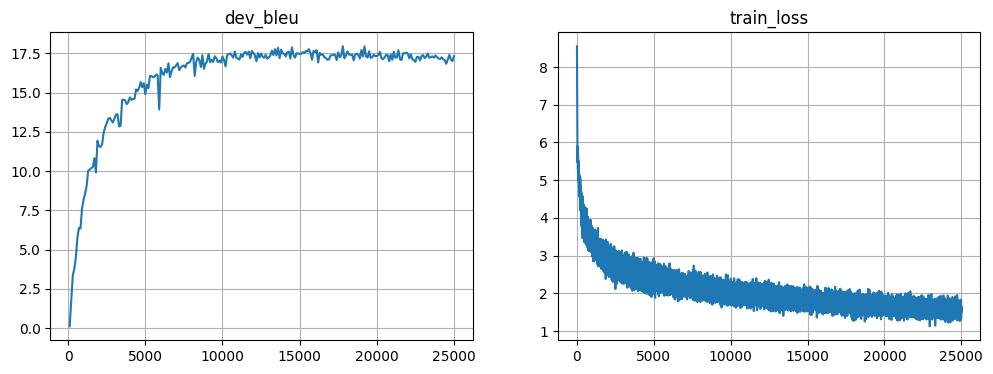

Mean loss=1.524


100%|██████████| 25000/25000 [2:57:08<00:00,  2.35it/s]


In [21]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    # --- BẮT ĐẦU PHẦN CODE CỦA BẠN ---
    
    # 1. Xóa bộ nhớ gradient của bước trước đó để tránh cộng dồn sai lệch
    opt.zero_grad() 
    
    # 2. Gọi hàm tính loss bạn đã viết ở bước trước để đo lường độ sai lệch của batch hiện tại
    loss_t = compute_loss(model, batch_inp, batch_out) 
    
    # 3. Lan truyền ngược (Backpropagation) để tính toán đạo hàm (gradient) cho tất cả các tham số
    loss_t.backward() 
    
    # 4. Yêu cầu bộ tối ưu hóa (Optimizer) cập nhật trọng số của mô hình dựa trên gradient vừa tính
    opt.step() 
    
    # --- KẾT THÚC PHẦN CODE CỦA BẠN ---

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

# Note: it's okay if bleu oscillates up and down as long as it gets better on average over long term (e.g. 5k batches)

In [22]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "We kind of need a higher bleu BLEU from you. Kind of right now."

In [23]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
guests have access to shared use of shared or shared lounge , and a shared kitchen .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
other facilities offered at the property include a shared kitchen and luggage storage .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
bolzano is 18 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located in the centre of lucca , this hotel features a swimming pool and sun terrace , and a 10 - minute drive from the beach .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
the apartment is located 450 metres from the cathedral and a 15 - minute walk from the holy trinity cathedral .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring 

lưu model lại

In [24]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt.state_dict(),
    "step": step,
    "metrics": metrics
}

torch.save(checkpoint, "basic_model.pth")

load đê train tiếp 

In [26]:
model_backup = BasicModel(
    inp_voc,
    out_voc,
    emb_size=64,
    hid_size=128
).to(device)

opt = torch.optim.Adam(model_backup.parameters())

checkpoint = torch.load(
    "basic_model.pth",
    map_location=device
)

model_backup.load_state_dict(
    checkpoint["model_state_dict"]
)

opt.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

step = checkpoint["step"]
metrics = checkpoint["metrics"]

sau đó có thể tiếp tục train: for _ in range(25000):
    ...

### Your Attention Required

In this section we want you to improve over the basic model by implementing a simple attention mechanism.

This is gonna be a two-parter: building the __attention layer__ and using it for an __attentive seq2seq model__.

### Scaled Dot Product (3 Points)
Here you will have to implement a layer that computes a **scaled dot-product attention**:

Given encoder sequence $h^e_0, h^e_1, h^e_2, \dots, h^e_T$ and a single decoder state $h^d$,

* Project the decoder state into a **query** vector
  $$q = W_q h^d$$
* Project encoder states into **keys** and **values**
  $$k_t = W_k h^e_t, \quad v_t = W_v h^e_t$$
* Compute logits as **scaled dot products** between the query and each key
  $$a_t = \frac{q \cdot k_t}{\sqrt{d_k}}$$
  where $d\_k$ is the key/query dimensionality.
* Convert logits into probabilities using softmax
  $$p_t = \frac{e^{a_t}}{\sum_\tau e^{a_\tau}}$$
* Add up encoder values with probabilities to get the **attention response**
  $$attn = \sum_t p_t \cdot v_t$$

In [49]:
import torch
import torch.nn as nn
import math

class DotProductAttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size):
        """
        Scaled dot-product attention with projections
        :param enc_size: num units in encoder state
        :param dec_size: num units in decoder state
        :param hid_size: dimension of query/key space (d_k)
        """
        super().__init__()
        self.name = name
        self.enc_size = enc_size
        self.dec_size = dec_size
        self.hid_size = hid_size

        # Define projection layers
        # W_q, W_k, W_v project decoder states into query, key, value
        # Chú thích: Thực tế W_q chiếu trạng thái của decoder thành Query, 
        # trong khi W_k và W_v chiếu trạng thái của encoder thành Key và Value.
        self.W_q = nn.Linear(dec_size, hid_size)
        self.W_k = nn.Linear(enc_size, hid_size)
        self.W_v = nn.Linear(enc_size, enc_size)

    def forward(self, enc, dec, inp_mask):
        """
        Compute attention response and weights
        :param enc: encoder sequence [batch_size, ninp, enc_size]
        :param dec: decoder state [batch_size, dec_size]
        :param inp_mask: mask [batch_size, ninp] (0 = padding)
        :returns: attn [batch_size, enc_size], probs [batch_size, ninp]
        """

        # Compute Q, K, V projections
        # 1. Tính toán các vector Q, K, V bằng cách đưa qua lớp mạng tuyến tính (Linear)
        Q = self.W_q(dec) # Kích thước: [batch_size, hid_size]
        K = self.W_k(enc) # Kích thước: [batch_size, ninp, hid_size]
        V = self.W_v(enc) # Kích thước: [batch_size, ninp, enc_size]

        # Compute logits as scaled dot product QK^T, do not forget 1 / sqrt(d)
        # Hint: You may want to expand Q to shape [batch_size, 1, hid_size]
        # 2. Tính điểm số (logits) bằng phép nhân ma trận giữa Q và K chuyển vị, sau đó chia cho sqrt(hid_size) để chuẩn hóa
        Q_expanded = Q.unsqueeze(1)               # Mở rộng Q thành [batch_size, 1, hid_size]
        K_transposed = K.transpose(1, 2)          # Chuyển vị K thành [batch_size, hid_size, ninp]
        
        # Nhân ma trận theo lô (batch matrix multiplication): [batch, 1, hid] x [batch, hid, ninp] = [batch, 1, ninp]
        logits = torch.bmm(Q_expanded, K_transposed) / math.sqrt(self.hid_size)
        logits = logits.squeeze(1)                # Thu gọn lại thành [batch_size, ninp]

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        # 3. Áp dụng mặt nạ (Masking): Nếu token là padding (mask == 0), ép điểm số về cực nhỏ (-1e9)
        # Việc này giúp Softmax sau đó biến xác suất tại các vị trí padding thành 0 (mô hình phớt lờ phần đệm).
        logits = torch.where(inp_mask == 0, torch.tensor(-1e9, dtype=logits.dtype, device=logits.device), logits)

        # Softmax
        # 4. Chuyển đổi điểm số thành phân phối xác suất (tổng bằng 1)
        probs = torch.softmax(logits, dim=-1)     # [batch_size, ninp]

        # Compute attention response
        # 5. Nhân trọng số xác suất (probs) với các vector Giá trị (V) để thu được vector Ngữ cảnh (Context/Attention vector)
        probs_expanded = probs.unsqueeze(1)       # Mở rộng probs thành [batch_size, 1, ninp]
        
        # Nhân ma trận: [batch, 1, ninp] x [batch, ninp, enc_size] = [batch, 1, enc_size]
        attn = torch.bmm(probs_expanded, V)
        attn = attn.squeeze(1)                    # Thu gọn thành [batch_size, enc_size]

        return attn, probs

### Seq2seq model with attention (3 points)

You can now use the attention layer to build a network. The simplest way to implement attention is to use it in decoder phase:
![img](https://i.imgur.com/6fKHlHb.png)
_image from distill.pub [article](https://distill.pub/2016/augmented-rnns/)_

On every step, use __previous__ decoder state to obtain attention response. Then feed concat this response to the inputs of next attention layer.

The key implementation detail here is __model state__. Put simply, you can add any tensor into the list of `encode` outputs. You will then have access to them at each `decode` step. This may include:
* Last RNN hidden states (as in basic model)
* The whole sequence of encoder outputs (to attend to) and mask
* Attention probabilities (to visualize)

_There are, of course, alternative ways to wire attention into your network and different kinds of attention. Take a look at [this](https://arxiv.org/abs/1609.08144), [this](https://arxiv.org/abs/1706.03762) and [this](https://arxiv.org/abs/1808.03867) for ideas. And for image captioning/im2latex there's [visual attention](https://arxiv.org/abs/1502.03044)_

In [67]:
import torch
import torch.nn as nn

class AttentiveModel(BasicModel): # Mặc dù kế thừa BasicModel nhưng theo template thì ta sẽ init lại các layer
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        nn.Module.__init__(self)  # initialize base class to track sub-layers, trainable variables, etc.
        self.name = name
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        
        # <YOUR CODE: initialize layers>
        # Khởi tạo lại các lớp y như BasicModel
        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)
        
        # Thêm lớp Attention (Bạn có thể dùng DotProductAttentionLayer hoặc AttentionLayer tùy ý)
        self.attention = DotProductAttentionLayer('attention', hid_size, hid_size, attn_size)
        
        # Sửa GRUCell: Đầu vào = Vector nhúng (emb_size) + Vector ngữ cảnh từ Attention (hid_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        
        # encode input sequence, create initial decoder states
        # <YOUR CODE>
        inp_emb = self.emb_inp(inp)
        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_start = self.dec_start(last_state)
        
        enc_mask = self.inp_voc.compute_mask(inp)
        
        # apply attention layer from initial decoder hidden state
        # <...> Tính xác suất attention ở ngay bước đầu tiên (trước khi dịch từ nào)
        _, first_attn_probas = self.attention(enc_seq, dec_start, enc_mask)
        
        # Build first state: include
        # * initial states for decoder recurrent layers -> dec_start
        # * encoder sequence and encoder attn mask (for attention) -> enc_seq, enc_mask
        # * make sure that last state item is attention probabilities tensor -> first_attn_probas
        
        first_state = [dec_start, enc_seq, enc_mask, first_attn_probas]
        return first_state
   
    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """
        
        # <YOUR CODE HERE>
        # Giải nén state (ta dùng dấu _ cho prev_probas vì bước này không dùng lại xác suất cũ để tính toán)
        prev_gru0_state, enc_seq, enc_mask, _ = prev_state

        # 1. Tính toán Attention để lấy Context vector (attn) và xác suất mới (probs)
        attn, probs = self.attention(enc_seq, prev_gru0_state, enc_mask)
        
        # 2. Lấy vector nhúng của từ trước đó
        prev_emb = self.emb_out(prev_tokens)
        
        # 3. Ghép nối (Concatenate) vector nhúng và Context vector
        rnn_input = torch.cat([prev_emb, attn], dim=-1)
        
        # 4. Cập nhật trạng thái GRU và tính logits
        new_gru0_state = self.dec0(rnn_input, prev_gru0_state)
        output_logits = self.logits(new_gru0_state)
        
        # Đóng gói trạng thái mới, NHỚ PHẢI ĐỂ probs Ở CUỐI CÙNG NHƯ YÊU CẦU
        new_dec_state = [new_gru0_state, enc_seq, enc_mask, probs]
        
        return new_dec_state, output_logits

### Training attentive model

Please reuse the infrastructure you've built for the regular model. I hope you didn't hard-code anything :)

In [ ]:
# # <YOUR CODE: create AttentiveModel and training utilities>
# import torch
# import torch.nn as nn
# from IPython.display import clear_output
# import matplotlib.pyplot as plt
# import numpy as np
# from tqdm import trange

# # Khởi tạo AttentiveModel kế thừa từ BasicModel
# class AttentiveModel(BasicModel):
#     def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
#         """
#         Translation model that uses attention.
#         Mô hình dịch thuật sử dụng cơ chế attention.
#         """
#         super().__init__(inp_voc, out_voc, emb_size, hid_size)
        
#         # Khởi tạo lớp Attention bạn vừa viết ở bước trước
#         self.attention = DotProductAttentionLayer('attention', hid_size, hid_size, attn_size)
        
#         # SỬA ĐỔI QUAN TRỌNG: Đầu vào của GRUCell bây giờ sẽ bao gồm 
#         # Vector nhúng của từ (emb_size) ghép nối (concat) với Vector ngữ cảnh từ Attention (hid_size)
#         self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)

#     def encode(self, inp, **flags):
#         """
#         Mã hóa đầu vào và trả về trạng thái khởi tạo cho decoder.
#         Lưu ý: Chúng ta cần trả về cả enc_seq và enc_mask để dùng cho Attention.
#         """
#         inp_emb = self.emb_inp(inp)
#         enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        
#         lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
#         last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
#         dec_start = self.dec_start(last_state)
        
#         # Tạo mặt nạ cho chuỗi mã hóa (để Attention bỏ qua padding)
#         enc_mask = self.inp_voc.compute_mask(inp)
        
#         # Trạng thái trả về giờ là một danh sách 3 phần tử
#         return [dec_start, enc_seq, enc_mask]

#     def decode_step(self, prev_state, prev_tokens, **flags):
#         """
#         Bước giải mã với Attention
#         """
#         prev_gru0_state, enc_seq, enc_mask = prev_state

#         # 1. Tính toán Attention để lấy Context vector (attn)
#         attn, probs = self.attention(enc_seq, prev_gru0_state, enc_mask)
        
#         # 2. Lấy vector nhúng của từ trước đó
#         prev_emb = self.emb_out(prev_tokens)
        
#         # 3. Ghép nối (Concatenate) vector nhúng và Context vector
#         rnn_input = torch.cat([prev_emb, attn], dim=-1)
        
#         # 4. Cập nhật trạng thái GRU và tính logits
#         new_gru0_state = self.dec0(rnn_input, prev_gru0_state)
#         output_logits = self.logits(new_gru0_state)
        
#         # Đóng gói trạng thái mới để chuyển cho bước tiếp theo
#         new_dec_state = [new_gru0_state, enc_seq, enc_mask]

#         return new_dec_state, output_logits

# # --- KHỞI TẠO MÔ HÌNH VÀ CÔNG CỤ HUẤN LUYỆN ---
# # Đảm bảo bạn đã khai báo device (vd: device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

# model = AttentiveModel(inp_voc, out_voc).to(device)
# opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# metrics = {'train_loss': [], 'dev_bleu': []}
# batch_size = 32

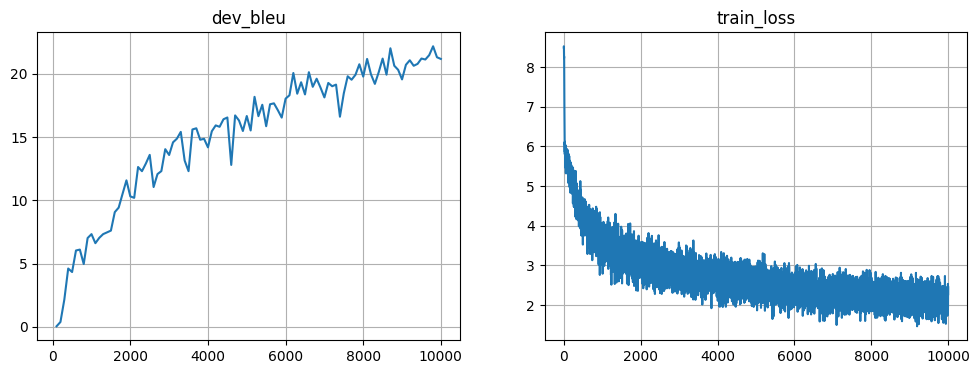

Mean loss=2.214


100%|██████████| 10000/10000 [2:43:33<00:00,  1.02it/s]


In [68]:
# Xác định tổng số bước bạn muốn train
# total_steps = 25000
total_steps = 10000
# Đếm số bước đã hoàn thành dựa vào lịch sử đã lưu trong metrics
completed_steps = len(metrics['train_loss'])

# Tính số bước còn lại
remaining_steps = total_steps - completed_steps

print(f"Mô hình đã hoàn thành {completed_steps}/{total_steps} bước.")
print(f"Đang tiếp tục huấn luyện {remaining_steps} bước còn lại...")

# <YOUR CODE: training loop>
# Vòng lặp huấn luyện mô hình có Attention
for _ in trange(remaining_steps):
    step = len(metrics['train_loss']) + 1
    
    # Lấy ngẫu nhiên một batch dữ liệu
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    # <YOUR CODE: training step using batch_inp and batch_out>
    opt.zero_grad() # Xóa gradient cũ / Clear gradients
    
    # Tính loss (đảm bảo hàm compute_loss của bạn gọi model(inp, out))
    loss_t = compute_loss(model, batch_inp, batch_out) 
    
    loss_t.backward() # Lan truyền ngược / Backpropagation
    opt.step()        # Cập nhật trọng số / Update weights
    # ========================================================

    metrics['train_loss'].append((step, loss_t.item()))

    # Đánh giá và vẽ biểu đồ mỗi 100 bước
    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

kiểm tra nghẽn 

In [39]:
import time
batch_size = 32
t0 = time.time()

loss_t = compute_loss(
    model,
    batch_inp,
    batch_out
)

loss_t.backward()
opt.step()

print(time.time() - t0)

0.46077466011047363


In [40]:
batch_size = 128
t0 = time.time()

loss_t = compute_loss(
    model,
    batch_inp,
    batch_out
)

loss_t.backward()
opt.step()

print(time.time() - t0)

0.4756462574005127


In [42]:
import time
batch_size = 32
t0 = time.time()
bleu = compute_bleu(model, dev_inp, dev_out)
print("BLEU time:", time.time() - t0)

BLEU time: 26.03984808921814


In [ ]:
import time
batch_size = 128
t0 = time.time()
bleu = compute_bleu(model, dev_inp, dev_out)
print("BLEU time:", time.time() - t0)

BLEU time: 24.663512229919434


In [70]:
# <YOUR CODE: measure final BLEU>

# Đánh giá trên tập kiểm tra (Test set) thay vì tập phát triển (Dev set)
test_bleu = compute_bleu(model, dev_inp, dev_out)

print(f"Final BLEU score on test set: {test_bleu:.2f}")

# (Tùy chọn) In thử một vài câu dịch để kiểm tra bằng mắt thường
print("\n--- Bản dịch thử nghiệm ---")
for i in range(5):
    # Lấy 5 câu bất kỳ từ tập test
    src = dev_inp[i]
    ref = dev_out[i]
    
    # Sử dụng hàm translate_lines đã có sẵn trong lớp BasicModel
    # Đưa vào dưới dạng list [src] và lấy kết quả đầu tiên [0]
    translation, _ = model.translate_lines([src])
    
    print(f"Input:       {src}")
    print(f"Reference:   {ref}")
    print(f"Translation: {translation[0]}")
    print("-" * 30)

Final BLEU score on test set: 21.17

--- Bản dịch thử nghiệm ---
Input:       в распоряжении гостей общая кухня и общая гостиная .
Reference:   a shared equipped kitchen and a common living room are provided to guests .
Translation: the property has a shared kitchen and a shared lounge .
------------------------------
Input:       на территории виллы sh@@ eng@@ si hu@@ a@@ jing находится сад и терраса .
Reference:   at sh@@ eng@@ si hua@@ jing villa you will find a garden and a terrace .
Translation: at the property by hilton garden you will find a garden and a terrace .
------------------------------
Input:       расстояние от отеля li@@ bu@@ š@@ e до ближайшей станции метро ko@@ by@@ lis@@ y ( линия с ), от которой можно добраться до центрального железнодорожного вокзала праги и центра города , составляет 500 метров .
Reference:   the nearest metro station at ko@@ by@@ lis@@ y , on line c , is set 500 metres from hotel li@@ bu@@ š@@ e , and it offers connections towards prague main t

In [69]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt.state_dict(),
    "step": step,
    "metrics": metrics
}

torch.save(checkpoint, "attention_model.pth")

### Visualizing model attention (2 points)

After training the attentive translation model, you can check it's sanity by visualizing its attention weights.

We provided you with a function that draws attention maps using [`Bokeh`](https://bokeh.pydata.org/en/latest/index.html). Once you managed to produce something better than random noise, please save at least 3 attention maps and __submit them to anytask__ alongside this notebook to get the max grade. Saving bokeh figures as __cell outputs is not enough!__ (TAs can't see saved bokeh figures in anytask). You can save bokeh images as screenshots or using this button:

![bokeh_panel](https://github.com/yandexdataschool/nlp_course/raw/2019/resources/bokeh_panel.png)

__Note:__ you're not locked into using bokeh. If you prefer a different visualization method, feel free to use that instead of bokeh.

In [53]:
!pip install bokeh

  Using cached bokeh-3.9.1-py3-none-any.whl.metadata (10 kB)
Using cached bokeh-3.9.1-py3-none-any.whl (6.4 MB)

   ---------------------------------------- 0/3 [xyzservices]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import bokeh.plotting as pl
import bokeh.models as bm
from bokeh.io import output_notebook, show
output_notebook()

def draw_attention(inp_line, translation, probs):
    """ An intentionally ambiguous function to visualize attention weights """
    inp_tokens = inp_voc.tokenize(inp_line)
    trans_tokens = out_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]

    fig = pl.figure(x_range=(0, len(inp_tokens)), y_range=(0, len(trans_tokens)),
                    x_axis_type=None, y_axis_type=None, tools=[])
    fig.image([probs[::-1]], 0, 0, len(inp_tokens), len(trans_tokens))

    fig.add_layout(bm.LinearAxis(axis_label='source tokens'), 'above')
    fig.xaxis.ticker = np.arange(len(inp_tokens)) + 0.5
    fig.xaxis.major_label_overrides = dict(zip(np.arange(len(inp_tokens)) + 0.5, inp_tokens))
    fig.xaxis.major_label_orientation = 45

    fig.add_layout(bm.LinearAxis(axis_label='translation tokens'), 'left')
    fig.yaxis.ticker = np.arange(len(trans_tokens)) + 0.5
    fig.yaxis.major_label_overrides = dict(zip(np.arange(len(trans_tokens)) + 0.5, trans_tokens[::-1]))
    show(fig)

Loading BokehJS ...

In [71]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
trans, states = model.translate_lines(train_inp[:3])

print("\nTranslations without training:")
print('\n'.join([line for line in trans]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
free private parking is available on site .
there are several restaurants , bars and restaurants within a 5 - minute walk of the property .
the hotel is located in the centre of culture , and the famous the river square and the famous cathedral of the town of saint museums .


In [72]:
import numpy as np

inp = dev_inp[::500]

trans, states = model.translate_lines(inp)

# select attention probs from model state (you may need to change this for your custom model)
# attention_probs below must have shape [batch_size, translation_length, input_length], extracted from states

# Lấy phần tử cuối cùng (-1) của mỗi state từ bước thứ 1 trở đi. 
# Ta phải dùng states[1:] vì states[0] là initial_state (trạng thái khởi tạo từ encoder, chưa có attention probs)
attention_probs = np.stack([state[-1].cpu().detach().numpy() for state in states[1:]], axis=1)

In [ ]:
# for i in range(5):
#     draw_attention(inp[i], trans[i], attention_probs[:, i])
# # Does it look fine already? don't forget to save images for anytask!

Loading BokehJS ...

In [73]:
import bokeh.plotting as pl
import bokeh.models as bm
# Đổi thư viện import từ output_notebook sang output_file
from bokeh.io import output_file, show 

# Khai báo tên file bạn muốn lưu
output_file("attention_plot.html")

# ... (Giữ nguyên hàm draw_attention và đoạn code chạy bên dưới của bạn) ...

for i in range(5):
    draw_attention(inp[i], trans[i], attention_probs[i])


--- Câu 1 ---


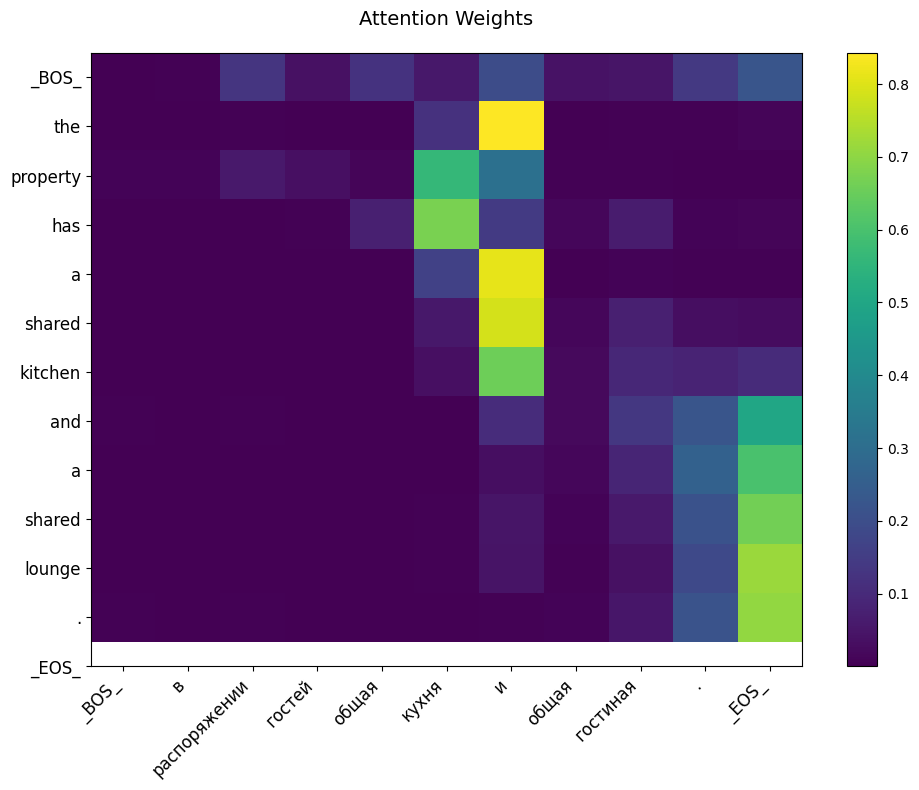


--- Câu 2 ---


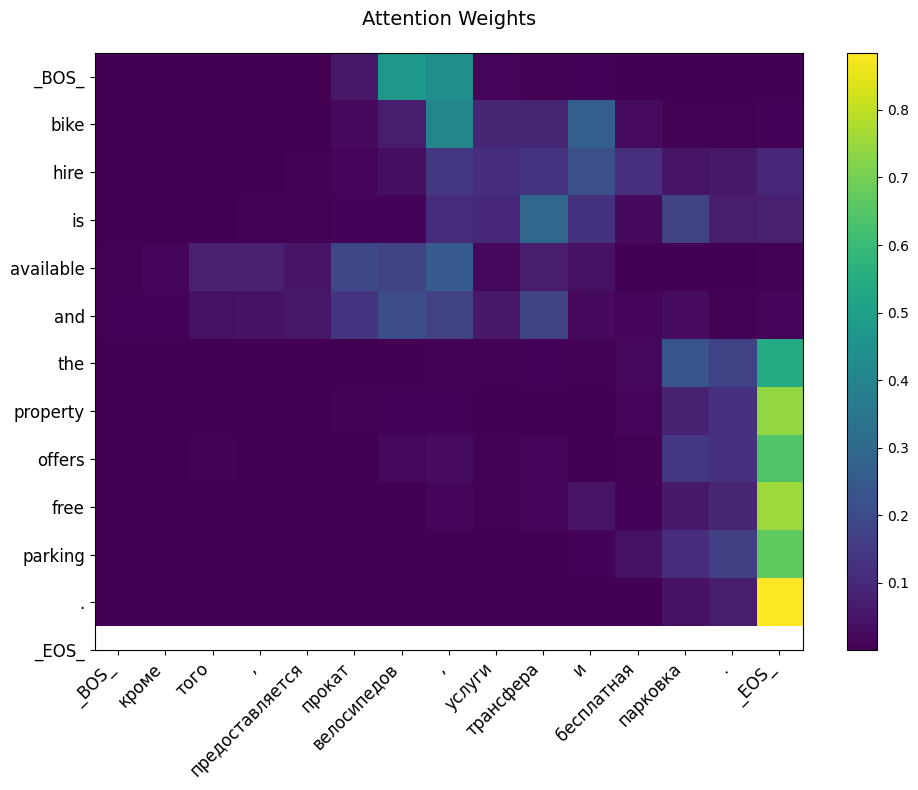


--- Câu 3 ---


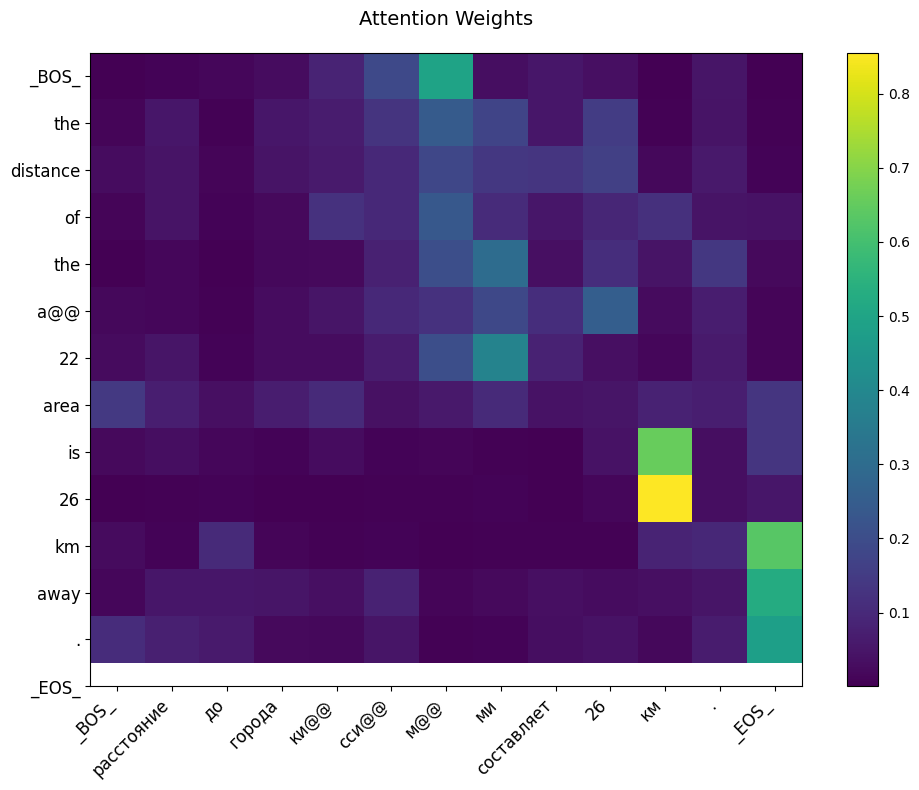


--- Câu 4 ---


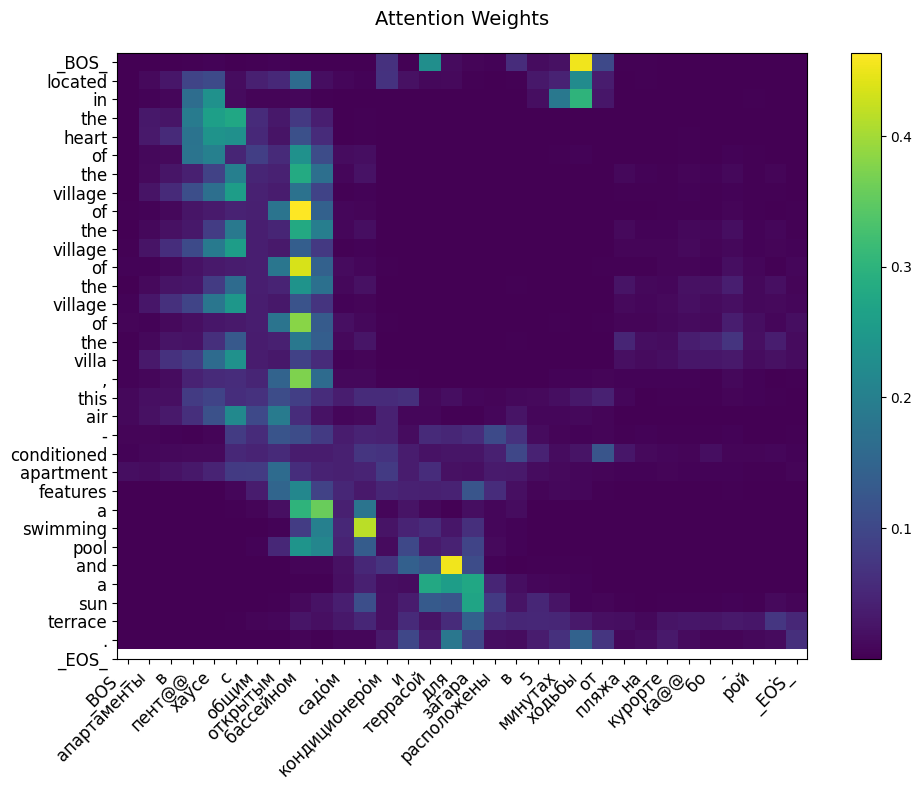


--- Câu 5 ---


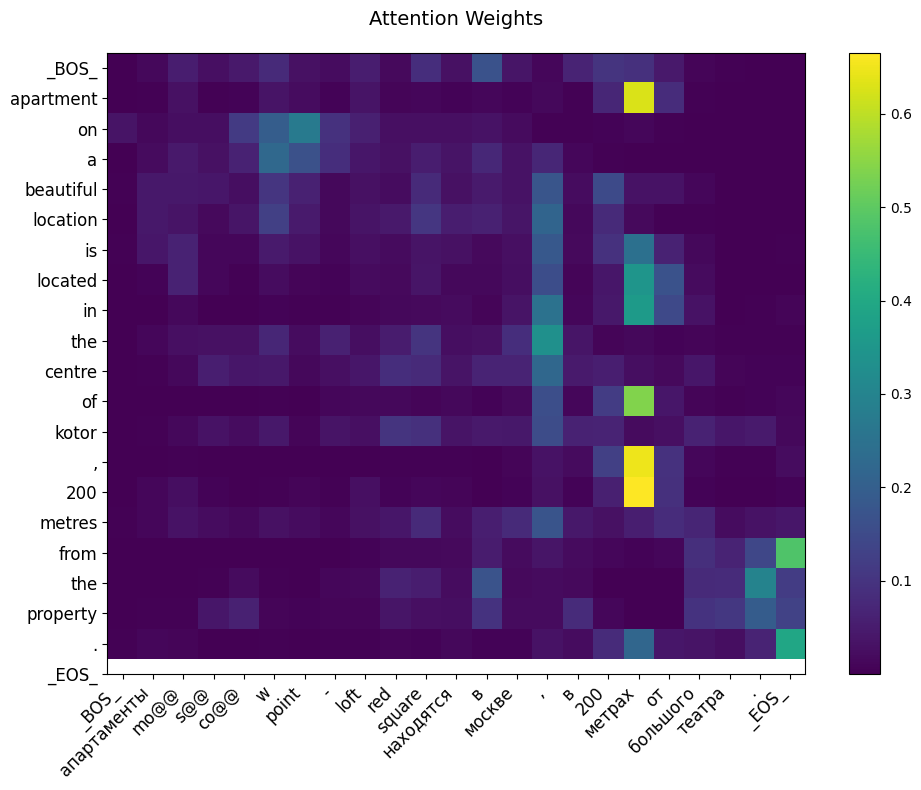

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_and_draw_attention(model, inp_line):
    # 1. Đưa câu đầu vào qua Encoder
    inp_matrix = model.inp_voc.to_matrix([inp_line]).to(device)
    initial_state = model.encode(inp_matrix)
    
    state = initial_state
    outputs = [torch.full([1], model.out_voc.bos_ix, dtype=torch.int64, device=device)]
    all_probs = []
    
    # 2. Chạy tay từng bước Decoder để hứng biến probs
    for i in range(100): # max_len = 100
        # Giải nén state theo index để không bị lỗi
        prev_gru0_state = state[0]
        enc_seq = state[1]
        enc_mask = state[2]
        
        # Tự gọi tay hàm attention để trích xuất probs
        attn, probs = model.attention(enc_seq, prev_gru0_state, enc_mask)
        all_probs.append(probs.cpu().detach().numpy()[0])
        
        # Gọi decode_step bình thường để đi tiếp
        state, logits = model.decode_step(state, outputs[-1])
        outputs.append(logits.argmax(dim=-1))
        
        # Dừng nếu dự đoán ra thẻ kết thúc câu (EOS)
        if outputs[-1].item() == model.out_voc.eos_ix:
            break
            
    # Lắp ghép dữ liệu
    trans_line = model.out_voc.to_lines(torch.stack(outputs, dim=1).cpu().numpy())[0]
    attention_probs = np.array(all_probs)
    
    # 3. Vẽ hình bằng Matplotlib
    inp_tokens = model.inp_voc.tokenize(inp_line)
    trans_tokens = model.out_voc.tokenize(trans_line)
    
    # Cắt ma trận cho khớp với độ dài thực tế của 2 câu
    attention_probs = attention_probs[:len(trans_tokens), :len(inp_tokens)]

    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(attention_probs, cmap='viridis', aspect='auto')

    ax.set_xticks(np.arange(len(inp_tokens)))
    ax.set_yticks(np.arange(len(trans_tokens)))

    ax.set_xticklabels(inp_tokens, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(trans_tokens, fontsize=12)

    fig.colorbar(cax)
    plt.title("Attention Weights", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# 4. Thử ngay cho 5 câu đầu tiên trong tập dữ liệu
for i in range(5):
    print(f"\n--- Câu {i+1} ---")
    get_and_draw_attention(model, inp[i])

__Note 1:__ If the attention maps are not iterpretable, try starting encoder from zeros (instead of dec_start), forcing model to use attention.

__Note 2:__ If you're studying this course as a YSDA student, please submit __attention screenshots__ alongside your notebook.

## Goind deeper (2++ points each)

We want you to find the best model for the task. Use everything you know.

* different recurrent units: rnn/gru/lstm; deeper architectures
* bidirectional encoder, different attention methods for decoder (additive, dot-product, multi-head)
* word dropout, training schedules, anything you can imagine
* replace greedy inference with beam search

For a better grasp of seq2seq We recommend you to conduct at least one experiment from one of the bullet-points or your alternative ideas. As usual, describe what you tried and what results you obtained in a short report.

`[your report/log here or anywhere you please]`

### (Optional 2+ points) Alternative Attention layer

You may compare scaled dot product with alternative additive attention implementation. Compare corresponding models metrics during training. Which is better?
___

Here you will have to implement a layer that computes a simple additive attention:

Given encoder sequence $ h^e_0, h^e_1, h^e_2, ..., h^e_T$ and a single decoder state $h^d$,

* Compute logits with a 2-layer neural network
$$a_t = linear_{out}(tanh(linear_{e}(h^e_t) + linear_{d}(h_d)))$$
* Get probabilities from logits,
$$ p_t = {{e ^ {a_t}} \over { \sum_\tau e^{a_\tau} }} $$

* Add up encoder states with probabilities to get __attention response__
$$ attn = \sum_t p_t \cdot h^e_t $$

You can learn more about attention layers in the lecture slides or [from this post](https://distill.pub/2016/augmented-rnns/).

In [63]:
import torch
import torch.nn as nn

class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.name = name
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units
        self.activ = activ       # attention layer hidden nonlinearity
        
        # create trainable paramteres like this:
        # self.<PARAMETER_NAME> = nn.Parameter(<INITIAL_VALUES>, requires_grad=True)
        
        # Khởi tạo các ma trận trọng số (weights) cho cơ chế Additive Attention.
        # Chúng ta khởi tạo ngẫu nhiên theo phân phối chuẩn (randn) và nhân với 0.02 
        # để các giá trị khởi tạo đủ nhỏ, giúp hàm tanh không bị bão hòa ngay từ đầu.
        self.W_enc = nn.Parameter(torch.randn(enc_size, hid_size) * 0.02, requires_grad=True)
        self.W_dec = nn.Parameter(torch.randn(dec_size, hid_size) * 0.02, requires_grad=True)
        self.V = nn.Parameter(torch.randn(hid_size) * 0.02, requires_grad=True)

    def forward(self, enc, dec, inp_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param inp_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """

        # Compute logits
        # 1. Tính điểm số (logits) thông qua phép cộng (Additive)
        
        # Chiếu enc và dec sang không gian ẩn (hidden space)
        # enc_proj: [batch_size, ninp, hid_size]
        enc_proj = torch.matmul(enc, self.W_enc)  
        
        # dec_proj: [batch_size, hid_size]
        dec_proj = torch.matmul(dec, self.W_dec)  
        
        # Cộng hai vector. Ta dùng unsqueeze(1) cho dec_proj để nó có shape [batch_size, 1, hid_size]
        # Pytorch sẽ tự động Broadcast (sao chép) nó ra cho mọi token trong chuỗi độ dài `ninp`.
        hidden_attn = enc_proj + dec_proj.unsqueeze(1) # [batch_size, ninp, hid_size]
        
        # Áp dụng hàm kích hoạt (mặc định là tanh) và nhân vô hướng với vector V để nén về 1 chiều
        # logits: [batch_size, ninp]
        logits = torch.matmul(self.activ(hidden_attn), self.V) 

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        # 2. Áp dụng mặt nạ (Masking) để phớt lờ các thẻ padding
        logits = torch.where(inp_mask == 0, torch.tensor(-1e9, dtype=logits.dtype, device=logits.device), logits)

        # Compute attention probabilities (softmax)
        # 3. Chuẩn hóa logits thành phân phối xác suất (tổng bằng 1)
        probs = torch.softmax(logits, dim=-1) # [batch_size, ninp]

        # Compute attention response using enc and probs
        # 4. Tính toán Vector Ngữ cảnh (Context vector / Attention vector) 
        # bằng cách nhân xác suất (probs) với các trạng thái của Encoder (enc)
        probs_expanded = probs.unsqueeze(1)   # [batch_size, 1, ninp]
        
        # Nhân ma trận lô: [batch, 1, ninp] x [batch, ninp, enc_size] = [batch, 1, enc_size]
        attn = torch.bmm(probs_expanded, enc) 
        attn = attn.squeeze(1)                # Thu gọn lại thành [batch_size, enc_size]

        return attn, probs